# Misc Plots

This notebook has miscellaneous not necessarily related plots that were used during this work.

In [2]:
# Get project root for file paths
from pathlib import Path
import pandas as pd

notebook_path = Path().resolve()
project_root = notebook_path.parent
data_dir = project_root / "data"
model_dir = data_dir / "models"
plots_dir = project_root / "output" / "notebook_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

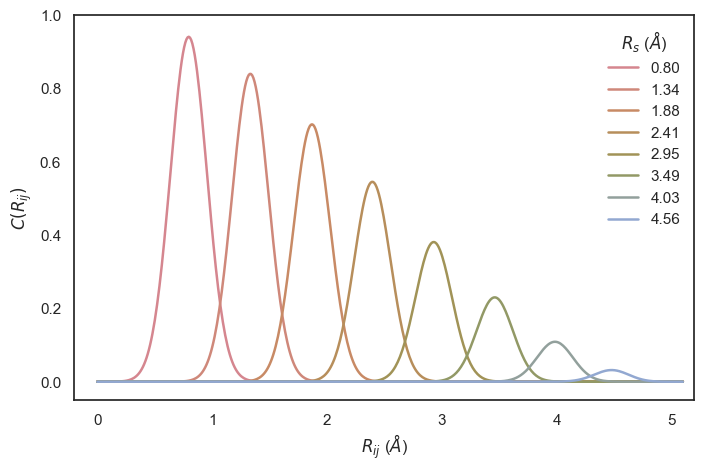

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
Rc = 5.1
eta = 19.7
Rs_values = [0.80, 1.34, 1.88, 2.41, 2.95, 3.49, 4.03, 4.56]

# Create a fine grid for the x-axis (distance Rij)
Rij = np.linspace(0, Rc, 500)

# Define the Cutoff Function
fc = 0.5 * (np.cos(np.pi * Rij / Rc) + 1)

sns.set_theme(style="white")
plt.figure(figsize=(8, 5))

color_list = ["#D5868F", "#C68B5E", "#929654", "#92A8D1"]

custom_palette = sns.blend_palette(color_list, n_colors=len(Rs_values))

# Plot each Gaussian
for i, Rs in enumerate(Rs_values):
    # Calculate the Gaussian component
    y = np.exp(-eta * (Rij - Rs)**2) * fc
    sns.lineplot(x=Rij, y=y, label=f'{Rs:.2f}', color=custom_palette[i], lw=1.8)

plt.xlabel('$R_{ij}$ ($\AA$)')
plt.ylabel('$C(R_{ij})$')
plt.legend(title='$R_s$ ($\AA$)',frameon=False, bbox_to_anchor=(1, 1))
plt.xlim(-0.2, Rc + 0.1)
plt.ylim(-0.05, 1.0)


plt.savefig(plots_dir / "AEV_Plot.pdf", bbox_inches='tight')
plt.show()